In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import importlib
import sys
import os

sys.path.append(
    os.path.abspath("../data_prepration")
)

import load_data
importlib.reload(load_data)

<module 'load_data' from 'e:\\DataAnalysis\\_Projects\\proj_17\\product_feature_performance_analysis\\data_prepration\\load_data.py'>

### **users table duplicates check**

In [5]:
users = load_data.load_users()
dups_count = users.duplicated().sum()
print (f"Duplicated Values Count: {dups_count}")

Duplicated Values Count: 0


#### Findings

No exact duplicate records were found in the users table.

### **users table missing value check**

In [16]:
missing_values_count = users.isna().sum().to_frame("Missing Values")
# print (f"Missing Values Count: {missing_values_count}")
missing_values_count["Total Rows"] = len(users)
missing_values_count["Percentage"] = (missing_values_count["Missing Values"] * 100 / missing_values_count["Total Rows"]).round(2)
missing_values_count

,Missing Values,Total Rows,Percentage
user_id,0,300000,0.00
signup_date,0,300000,0.00
country,0,300000,0.00
city,0,300000,0.00
age_group,0,300000,0.00
customer_type,0,300000,0.00
is_premium,0,300000,0.00
premium_start_date,201086,300000,67.03
acquisition_channel,0,300000,0.00
device_type,0,300000,0.00


`premium_start_date` column is missing **67.03%** of its value which is not an issues.
**it means 67.03% of our users are not Premium users**  

In [18]:
users["user_id"].is_unique

True

`user_id` column ha no duplicated id

### **Country Distribution**

This analysis examines the geographical distribution of users across different countries.

In [23]:
users_distribution_by_country = (
    users
        .groupby("country")
        .agg(
            users_count = ("user_id", "count")
        )
        .sort_values("users_count", ascending = False)
)
users_distribution_by_country["percentage"] = (users_distribution_by_country["users_count"] * 100 / users_distribution_by_country["users_count"].sum()).round(2)
users_distribution_by_country

,users_count,percentage
country,,
Egypt,95752,31.92
Saudi Arabia,69090,23.03
UAE,54109,18.04
Kuwait,35958,11.99
Jordan,24171,8.06
Qatar,11902,3.97
Bahrain,9018,3.01


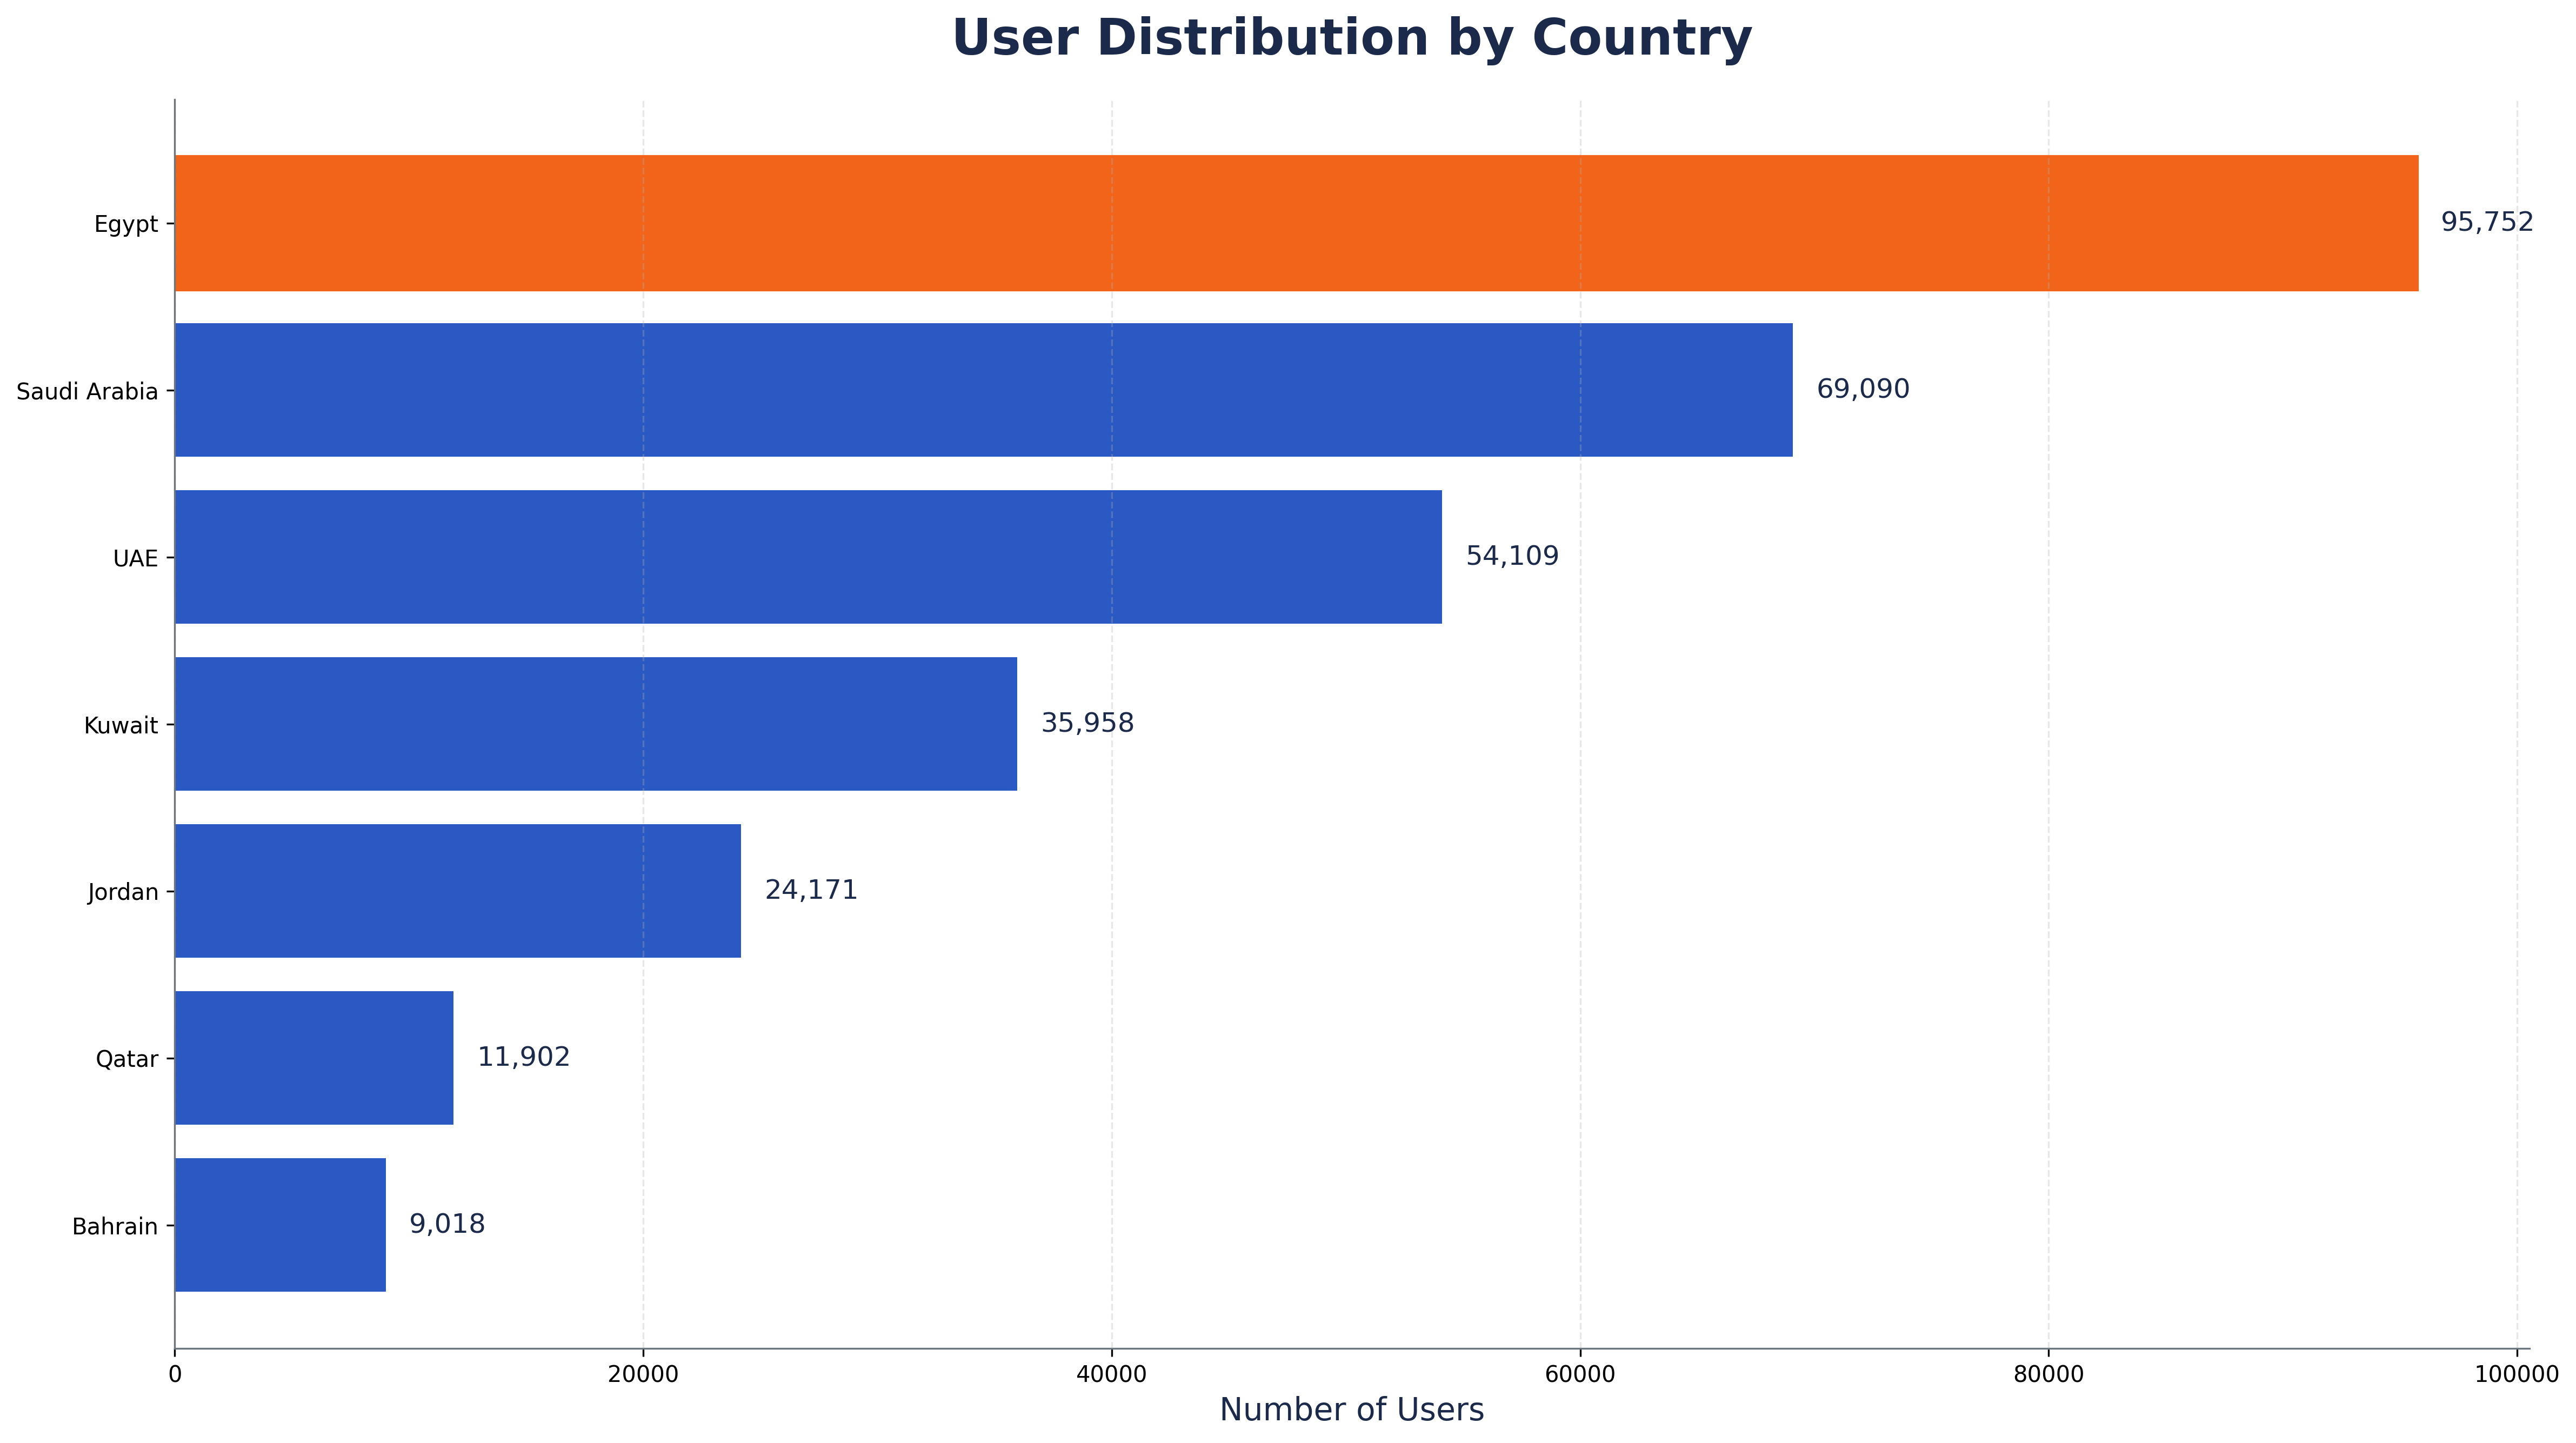

In [ ]:
plt.figure(figsize=(16, 9), dpi=300)

bars = plt.barh(
    users_distribution_by_country.index,
    users_distribution_by_country["users_count"],
    color="#2B59C3"
)

bars[0].set_color("#F26419")

plt.title(
    "User Distribution by Country",
    fontsize=22,
    fontweight="bold",
    color="#1B2A4A",
    pad=20
)

plt.xlabel(
    "Users Count",
    fontsize=14,
    color="#1B2A4A"
)

plt.ylabel("")

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

plt.gca().invert_yaxis()

ax = plt.gca()

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_color("#6C757D")
ax.spines["bottom"].set_color("#6C757D")

for i, value in enumerate(users_distribution_by_country["users_count"]):
    plt.text(
        value + 1000,
        i,
        f"{value:,}",
        va="center",
        fontsize=12,
        color="#1B2A4A"
    )

plt.tight_layout()

plt.savefig(
    "../charts/1.users_distribution_by_country.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()